# 23_02 다중센서 패턴 분석

In [13]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 1. 시간 인덱싱과 슬라이싱
### 목표
글자 날짜를 시간 형식으로 바꿔 인덱스로 올리고 날짜로 구간 자르기
### 단계
- 시각 열의 자료형을 확인하고 시간 형식으로 변환
- 시간 열을 인덱스로 올리기
- 하루·기간을 날짜로 잘라 행 수 확인
### 예상 결과
자료형이 시간으로 바뀌고, 하루 24행·사흘 72행

In [14]:
# 실습 1 코드
TS = "../csv/23_cmapss_unit1_timestamp.csv"

ts = pd.read_csv(TS)
ts['timestamp'] = pd.to_datetime(ts['timestamp'])
ts = ts.set_index('timestamp')
# ts.info()
# ts.head()

print(len(ts.loc['2024-01-02'])) # 24
print(len(ts.loc['2024-01-03':"2024-01-05"])) # 72


24
72


## 실습 2. 리샘플링 집계와 시간 이동통계
### 목표
시간 단위로 리샘플링해 대표값을 구하고 일별 이동평균으로 추세를 보기
### 단계
- 하루 단위 평균과 6시간 단위 평균을 각각 구하기
- 각 결과의 개수로 단위 차이를 확인
- 일별 평균에 이동평균을 걸어 추세를 매끄럽게
### 예상 결과
하루 평균 8개·6시간 평균 32개, 일별 값이 상승 추세

In [15]:
# 실습 2 코드
# 하루 단위 평균
daily = ts['sensor_3'].resample("1D").mean()

print("하루단위 평균 : ", daily.round(2))
print("하루 평균 개수 : ", len(daily))
# print("하루단위 평균 : ", daily.round(2).tolist())

sixhours = ts['sensor_3'].resample('6h').mean()
print("6시간 평균 : ", daily.round(2))

daily_ma = daily.rolling(3).mean().round(2)

print("하루단위 평균의 이동평균 계산 : ", daily_ma)



하루단위 평균 :  timestamp
2024-01-01    1592.12
2024-01-02    1590.92
2024-01-03    1593.35
2024-01-04    1597.82
2024-01-05    1603.70
2024-01-06    1610.59
2024-01-07    1614.09
2024-01-08    1628.51
Freq: D, Name: sensor_3, dtype: float64
하루 평균 개수 :  8
6시간 평균 :  timestamp
2024-01-01    1592.12
2024-01-02    1590.92
2024-01-03    1593.35
2024-01-04    1597.82
2024-01-05    1603.70
2024-01-06    1610.59
2024-01-07    1614.09
2024-01-08    1628.51
Freq: D, Name: sensor_3, dtype: float64
하루단위 평균의 이동평균 계산 :  timestamp
2024-01-01        NaN
2024-01-02        NaN
2024-01-03    1592.13
2024-01-04    1594.03
2024-01-05    1598.29
2024-01-06    1604.04
2024-01-07    1609.46
2024-01-08    1617.73
Freq: D, Name: sensor_3, dtype: float64


## 실습 3. 다중센서 정규화와 겹쳐 비교
### 목표
여러 센서를 0~1로 정규화해 같은 눈금에서 함께 비교
### 단계
· 세 센서를 최소·최대 기준으로 0~1로 정규화
· 정규화 후 최솟값·최댓값이 0과 1인지 확인
· 이동평균을 걸어 겹쳐 그릴 준비
### 예상 결과
각 센서의 최솟값 0·최댓값 1로 눈금이 맞춰짐

In [16]:
# 실습 3 코드
df = pd.read_csv('../csv/23_cmapss_fd001_sample.csv')

u2 = df[df['unit_number'] == 2].copy().reset_index(drop=True)

# 특정 컬럼 선택
cols = ['sensor_2', 'sensor_7', 'sensor_11']

# 정규화

norm = (u2[cols] - u2[cols].min()) / (u2[cols].max() - u2[cols].min()) # 정규화 (값 - 최소값) / (최대값 - 최소값)

print(norm.min().tolist(), norm.max().tolist())

norm.describe()

norm_ma = norm.rolling(window=10).mean()
norm_ma.tail()

[0.0, 0.0, 0.0] [1.0, 1.0, 1.0]


,sensor_2,sensor_7,sensor_11
282,0.810044,0.265352,0.669533
283,0.834185,0.256870,0.697009
284,0.820176,0.272103,0.675140
285,0.849604,0.282139,0.685981
286,0.861498,0.241995,0.636822


## 실습 4. 다중센서 변화 폭 비교
### 목표
정규화한 여러 센서의 초반·후반 값을 비교해 변화 폭이 큰 센서를 찾기
### 단계
- 여섯 센서를 정규화하고 이동평균을 걸기
- 각 센서의 초반과 후반 평균을 구하기
- 초반·후반 차이로 변화 폭이 큰 감시 센서 선별
### 예상 결과
sensor_2는 크게 상승, sensor_7은 하락 — 변화 폭 큰 센서 부각

In [17]:
# 실습 4 코드
sensors = [
    'sensor_2',
    'sensor_3',
    'sensor_4',
    'sensor_7',
    'sensor_11',
    'sensor_15'
]
n6 = (u2[sensors] - u2[sensors].min()) / (u2[sensors].max() - u2[sensors].min())

n6_ma = n6.rolling(10).mean()

for c in ['sensor_2', 'sensor_7', 'sensor_11']:
    early = n6_ma[c].iloc[10:40].mean()
    last = n6_ma[c].iloc[150:].mean()
    print(c, round(early, 2), round(last, 2), round(last - early, 2))

sensor_2 0.07 0.53 0.46
sensor_7 0.9 0.49 -0.41
sensor_11 0.13 0.39 0.26


## 실습 5. 다중센서 상관 heatmap
### 목표
여러 센서의 상관행렬을 구해 heatmap으로 함께 움직이는 센서를 파악
### 단계
- 여섯 센서의 상관행렬을 계산
- 히트맵으로 색과 숫자를 함께 표시
- 진한 칸으로 강한 양·음 관계를 읽기
### 예상 결과
sensor_2와 sensor_7이 강한 음(-0.96), sensor_2와 sensor_11이 양(0.84)


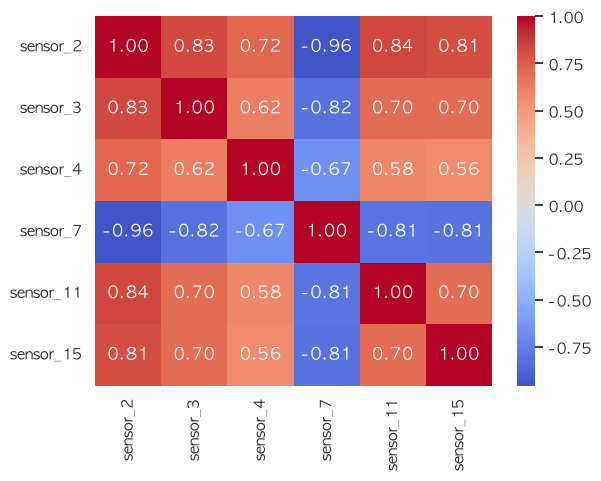

In [ ]:
# 실습 5 코드
# 상관관계
# 양의 상관관계 -> 한 쪽 증가 - 다른 쪽 증가
# 음의 상관관계 -> 한 쪽 증가 - 다른 쪽 감소
corr = u2[sensors].corr()

# corr.head()

sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='0.2f', center=0)

plt.show()


## 실습 6. 상관 높은 센서쌍 추출
### 목표
상관행렬에서 대각선을 빼고 가장 강한 음·양의 센서쌍을 추출
### 단계
- 상관행렬에서 자기 자신 대각선을 제외
- 센서쌍을 상관값 순으로 정렬
- 가장 강한 음의 쌍과 양의 쌍을 확인
### 예상 결과
음의 최강쌍 sensor_2·sensor_7(-0.955), 양의 최강쌍 sensor_2·sensor_11(0.839)

In [19]:
# 실습 6 코드

pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
pairs = pairs[pairs.index.map(lambda x: x[0] < x[1])].sort_values()
print('음:', pairs.index[0], round(pairs.iloc[0], 3))    # ('sensor_2','sensor_7') -0.955
print('양:', pairs.index[-1], round(pairs.iloc[-1], 3))   # ('sensor_11','sensor_2') 0.839

음: ('sensor_2', 'sensor_7') -0.955
양: ('sensor_11', 'sensor_2') 0.839


## 실습 7. 종합 통합 분석
### 목표
이동통계·변화점을 계산하고 구간별로 나눠 이상 의심 구간을 도출
### 단계
- 이동평균·이동표준편차·변화점을 한 번에 계산
- 초반·후반 변동성과 변화점 개수를 요약
- 회차 구간별 변동성·변화점으로 이상 의심 구간 찾기
### 예상 결과
후반 변동성이 커지고 변화점 19개, 216~288 구간에 집중

In [20]:
# 실습7 코드

for c in sensors:
    s = u2[c]
    u2['ma'] = s.rolling(10).mean()
    u2['std'] = s.rolling(10).std()
    resid = s - u2['ma']
    u2['chg'] = resid.abs() > 2 * resid.std()
    print("=" * 40)
    # print(f'{c} 변동성 초반/후반:', round(u2['std'].iloc[10:50].mean(), 3), round(u2['std'].iloc[150:].mean(), 3))
    # print(f'{c} 변화점:', int(u2['chg'].sum()))
    for lo, hi in ((0, 72), (72, 144), (144, 216), (216, 288)):
        seg = u2[(u2.time_cycles > lo) & (u2.time_cycles <= hi)]
        print(f'{c}의 {lo}~{hi}: 변동성 {seg["std"].mean():.3f}, 변화점 {int(seg["chg"].sum())}개')


sensor_2의 0~72: 변동성 0.304, 변화점 0개
sensor_2의 72~144: 변동성 0.311, 변화점 1개
sensor_2의 144~216: 변동성 0.295, 변화점 0개
sensor_2의 216~288: 변동성 0.723, 변화점 18개
sensor_3의 0~72: 변동성 5.897, 변화점 0개
sensor_3의 72~144: 변동성 6.183, 변화점 0개
sensor_3의 144~216: 변동성 6.449, 변화점 2개
sensor_3의 216~288: 변동성 12.277, 변화점 11개
sensor_4의 0~72: 변동성 8.986, 변화점 0개
sensor_4의 72~144: 변동성 8.198, 변화점 0개
sensor_4의 144~216: 변동성 9.593, 변화점 1개
sensor_4의 216~288: 변동성 18.187, 변화점 12개
sensor_7의 0~72: 변동성 0.575, 변화점 0개
sensor_7의 72~144: 변동성 0.575, 변화점 0개
sensor_7의 144~216: 변동성 0.633, 변화점 1개
sensor_7의 216~288: 변동성 1.430, 변화점 13개
sensor_11의 0~72: 변동성 0.271, 변화점 0개
sensor_11의 72~144: 변동성 0.263, 변화점 0개
sensor_11의 144~216: 변동성 0.303, 변화점 1개
sensor_11의 216~288: 변동성 0.767, 변화점 16개
sensor_15의 0~72: 변동성 0.036, 변화점 0개
sensor_15의 72~144: 변동성 0.037, 변화점 0개
sensor_15의 144~216: 변동성 0.033, 변화점 1개
sensor_15의 216~288: 변동성 0.092, 변화점 18개
